In [ ]:
import math
import time
import random
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple, Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    accuracy_score,
)
from xgboost import XGBClassifier

# import optuna
# from optuna.samplers import TPESampler


GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

# Default continuous search space
SEARCH_SPACE = {
    "learning_rate": (0.01, 0.30),
    "subsample": (0.50, 1.00),
    "colsample_bytree": (0.50, 1.00),
    "reg_lambda": (1e-3, 10.0),
    "reg_alpha": (0.0, 5.0),
    "max_depth": (3, 10),      # integer
    "threshold": (0.05, 0.95),
}

PARAM_ORDER = [
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "max_depth",
    "threshold",
]

INTEGER_PARAMS = {"max_depth"}

In [ ]:
def _make_numeric_bundle_from_sklearn_dataset(dataset, name: str):
    X = pd.DataFrame(dataset.data, columns=getattr(dataset, "feature_names", None))
    if X.columns.isnull().any():
        X.columns = [f"f{i}" for i in range(X.shape[1])]
    y = pd.Series(dataset.target, name="target")

    return {
        "name": name,
        "X": X,
        "y": y,
        "categorical_cols": [],
        "numerical_cols": X.columns.tolist(),
    }


def load_dataset_breast_cancer():
    ds = load_breast_cancer()
    return _make_numeric_bundle_from_sklearn_dataset(ds, "breast_cancer")


def load_dataset_wine():
    ds = load_wine()
    return _make_numeric_bundle_from_sklearn_dataset(ds, "wine")


def load_dataset_digits():
    ds = load_digits()
    return _make_numeric_bundle_from_sklearn_dataset(ds, "digits")


def load_dataset_adult_openml():
    """
    Optional: requires internet.
    """
    X, y = fetch_openml(name="adult", version=2, as_frame=True, return_X_y=True)
    y = pd.Series((y.astype(str) == ">50K").astype(int), name="target")

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numerical_cols = [c for c in X.columns if c not in categorical_cols]

    return {
        "name": "adult_openml",
        "X": X,
        "y": y,
        "categorical_cols": categorical_cols,
        "numerical_cols": numerical_cols,
    }


def get_public_datasets(include_adult: bool = False):
    datasets = [
        load_dataset_breast_cancer(),
        load_dataset_wine(),
        load_dataset_digits(),
    ]
    if include_adult:
        try:
            datasets.append(load_dataset_adult_openml())
        except Exception as e:
            print(f"Skipping Adult/OpenML due to error: {e}")
    return datasets


datasets = get_public_datasets(include_adult=False)
for d in datasets:
    print(d["name"], d["X"].shape, d["y"].nunique())

breast_cancer (569, 30) 2
wine (178, 13) 3
digits (1797, 64) 10


In [ ]:
def make_splits(
    dataset_bundle: Dict[str, Any],
    random_state: int = GLOBAL_SEED,
    test_size: float = 0.20,
    valid_size_within_train: float = 0.25,
):
    X = dataset_bundle["X"]
    y = dataset_bundle["y"]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full,
        y_train_full,
        test_size=valid_size_within_train,
        random_state=random_state,
        stratify=y_train_full,
    )

    categorical_cols = dataset_bundle["categorical_cols"]
    numerical_cols = dataset_bundle["numerical_cols"]

    if len(categorical_cols) > 0:
        preprocess = ColumnTransformer(
            transformers=[
                (
                    "cat",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]),
                    categorical_cols,
                ),
                (
                    "num",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]),
                    numerical_cols,
                ),
            ],
            remainder="drop",
        )
    else:
        preprocess = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]),
                    numerical_cols,
                ),
            ],
            remainder="drop",
        )

    return {
        "name": dataset_bundle["name"],
        "X_train": X_train,
        "y_train": y_train,
        "X_valid": X_valid,
        "y_valid": y_valid,
        "X_test": X_test,
        "y_test": y_test,
        "preprocess": preprocess,
        "n_classes": int(y.nunique()),
    }


split_example = make_splits(datasets[0], random_state=42)
print(split_example["name"], split_example["X_train"].shape, split_example["n_classes"])

breast_cancer (341, 30) 2


In [ ]:
init_params = {
    "learning_rate": 0.10,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "max_depth": 6,
    "threshold": 0.50,
}

def clip_params(params: Dict[str, float]) -> Dict[str, float]:
    out = {}
    for k, v in params.items():
        lo, hi = SEARCH_SPACE[k]
        out[k] = float(np.clip(v, lo, hi))
    return out


def params_to_vector(params: Dict[str, float], param_order: List[str]) -> np.ndarray:
    return np.array([params[p] for p in param_order], dtype=float)


def vector_to_params(vec: np.ndarray, param_order: List[str]) -> Dict[str, float]:
    return {p: float(vec[i]) for i, p in enumerate(param_order)}


def build_xgb_pipeline(preprocess, params, n_classes, random_state=42):
    params = params.copy()

    # enforce integer
    params["max_depth"] = int(round(params["max_depth"]))
    params["max_depth"] = int(np.clip(params["max_depth"], 3, 10))

    if n_classes == 2:
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=200,
            max_depth=params["max_depth"],
            tree_method="hist",
            n_jobs=-1,
            random_state=random_state,
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            reg_alpha=params["reg_alpha"],
        )
    else:
        model = XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            n_estimators=200,
            max_depth=params["max_depth"],
            tree_method="hist",
            n_jobs=-1,
            random_state=random_state,
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            reg_alpha=params["reg_alpha"],
        )

    return Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])

def soft_tp_fp(proba, y_true, threshold, k=20.0):
    """
    Smooth approximation of TP / FP
    """
    s = 1.0 / (1.0 + np.exp(-k * (proba - threshold)))

    pos_mask = (y_true == 1)
    neg_mask = (y_true == 0)

    tpr = np.sum (s[pos_mask]) / (np.sum(pos_mask) + 1e-8)
    fpr = np.sum(s[neg_mask]) / (np.sum(neg_mask) + 1e-8)

    return tpr, fpr



def evaluate_params(
    params: Dict[str, float],
    data: Dict[str, Any],
    random_state: int = GLOBAL_SEED,
    verbose: bool = False,
) -> Dict[str, float]:
    params = clip_params(params)

    pipe = build_xgb_pipeline(
        preprocess=data["preprocess"],
        params=params,
        n_classes=data["n_classes"],
        random_state=random_state,
    )

    start = time.time()
    pipe.fit(data["X_train"], data["y_train"])
    elapsed = time.time() - start

    proba = pipe.predict_proba(data["X_valid"])
    pred = pipe.predict(data["X_valid"])

    acc = accuracy_score(data["y_valid"], pred)

    if data["n_classes"] == 2:
        auc = roc_auc_score(data["y_valid"], proba[:, 1])
        ll = log_loss(data["y_valid"], proba)
    else:
        auc = np.nan
        ll = log_loss(data["y_valid"], proba)

    # Main scalar comparison metric
    # Use accuracy across all datasets for consistency
    score = acc

    out = {
        "score": float(score),
        "accuracy": float(acc),
        "logloss": float(ll),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "elapsed_sec": float(elapsed),
    }

    if verbose:
        print("Params:", params)
        print("Metrics:", out)

    return out


def evaluate_vector_metrics(
    params: Dict[str, float],
    data: Dict[str, Any],
    random_state: int = GLOBAL_SEED,
) -> np.ndarray:
    """
    Vector objective for proposed method:
    P(phi) = [accuracy, 1 / (1 + logloss)]
    """
    metrics = evaluate_params(params, data, random_state=random_state)
    return np.array([
        metrics["accuracy"],
        1.0 / (1.0 + metrics["logloss"]),
    ], dtype=float)


# default_params = {
#     "learning_rate": 0.10,
#     "subsample": 0.80,
#     "colsample_bytree": 0.80,
#     "reg_lambda": 1.0,
# }
default_params = init_params
print(evaluate_params(default_params, split_example, verbose=True))
print(evaluate_vector_metrics(default_params, split_example))

Params: {'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'max_depth': 6.0, 'threshold': 0.5}
Metrics: {'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11211816312285612, 'auc': 0.9931215198165738, 'elapsed_sec': 0.12038683891296387}
{'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11211816312285612, 'auc': 0.9931215198165738, 'elapsed_sec': 0.12038683891296387}
[0.97368421 0.89918503]


In [ ]:
# grid search baseline
def run_grid_search(
    data: Dict[str, Any],
    random_state: int = GLOBAL_SEED,
) -> Dict[str, Any]:
    param_grid = {
        "learning_rate": [0.03, 0.05, 0.08, 0.10, 0.15],
        "subsample": [0.60, 0.75, 0.90, 1.00],
        "colsample_bytree": [0.60, 0.75, 0.90, 1.00],
        "reg_lambda": [0.01, 0.10, 1.0, 5.0],
    }

    history = []
    best_score = -np.inf
    best_params = None
    best_metrics = None

    for i, params in enumerate(ParameterGrid(param_grid)):
        metrics = evaluate_params(params, data, random_state=random_state)
        row = {"eval_id": i, **params, **metrics}
        history.append(row)

        if metrics["score"] > best_score:
            best_score = metrics["score"]
            best_params = params.copy()
            best_metrics = metrics.copy()

    return {
        "best_params": best_params,
        "best_metrics": best_metrics,
        "history": pd.DataFrame(history),
    }

In [ ]:
# Random search baseline
def sample_random_params(rng: np.random.Generator) -> Dict[str, float]:
    return {
        "learning_rate": rng.uniform(*SEARCH_SPACE["learning_rate"]),
        "subsample": rng.uniform(*SEARCH_SPACE["subsample"]),
        "colsample_bytree": rng.uniform(*SEARCH_SPACE["colsample_bytree"]),
        "reg_lambda": float(np.exp(
            rng.uniform(np.log(SEARCH_SPACE["reg_lambda"][0]), np.log(SEARCH_SPACE["reg_lambda"][1]))
        )),
    }


def run_random_search(
    data: Dict[str, Any],
    n_trials: int = 30,
    random_state: int = GLOBAL_SEED,
) -> Dict[str, Any]:
    rng = np.random.default_rng(random_state)
    history = []
    best_score = -np.inf
    best_params = None
    best_metrics = None

    for i in range(n_trials):
        params = sample_random_params(rng)
        metrics = evaluate_params(params, data, random_state=random_state)
        row = {"eval_id": i, **params, **metrics}
        history.append(row)

        if metrics["score"] > best_score:
            best_score = metrics["score"]
            best_params = params.copy()
            best_metrics = metrics.copy()

    return {
        "best_params": best_params,
        "best_metrics": best_metrics,
        "history": pd.DataFrame(history),
    }

In [ ]:
!pip install optuna
import optuna
from optuna.samplers import TPESampler
# bayesian optimization baseline with Optunma/TPE
def run_bayesian_optuna_tpe(
    data: Dict[str, Any],
    n_trials: int = 30,
    random_state: int = GLOBAL_SEED,
) -> Dict[str, Any]:
    history = []

    def objective(trial: optuna.Trial) -> float:
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30),
            "subsample": trial.suggest_float("subsample", 0.50, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        }
        metrics = evaluate_params(params, data, random_state=random_state)
        history.append({"eval_id": trial.number, **params, **metrics})
        return metrics["score"]

    sampler = TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params
    best_metrics = evaluate_params(best_params, data, random_state=random_state)

    return {
        "best_params": best_params,
        "best_metrics": best_metrics,
        "history": pd.DataFrame(history),
        "study": study,
    }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [ ]:
# test breast cancer
data_single = make_splits(load_dataset_breast_cancer(), random_state=42)

res_newton = run_newton_hpo(data_single, default_params, n_iter=8, random_state=42)
res_random = run_random_search(data_single, n_trials=20, random_state=42)
res_bo = run_bayesian_optuna_tpe(data_single, n_trials=20, random_state=42)

print("Newton:", res_newton.best_metrics, res_newton.best_params)
print("Random:", res_random["best_metrics"], res_random["best_params"])
print("BO/TPE :", res_bo["best_metrics"], res_bo["best_params"])

# Grid is usually slower; run after the others
res_grid = run_grid_search(data_single, random_state=42)
print("Grid:", res_grid["best_metrics"], res_grid["best_params"])

[I 2026-04-07 00:10:48,994] A new study created in memory with name: no-name-49d3f6cf-15ec-44a4-952b-8827424b9ead
[I 2026-04-07 00:10:49,109] Trial 0 finished with value: 0.9473684210526315 and parameters: {'learning_rate': 0.11861663446573512, 'subsample': 0.9753571532049581, 'colsample_bytree': 0.8659969709057025, 'reg_lambda': 0.24810409748678125}. Best is trial 0 with value: 0.9473684210526315.
[I 2026-04-07 00:10:49,210] Trial 1 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.055245405728306586, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_lambda': 2.9154431891537547}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:10:49,299] Trial 2 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.18432335340553055, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'reg_lambda': 7.579479953348009}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:10:49,365] 

Newton: {'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11485750174520083, 'auc': 0.9921388797903701, 'elapsed_sec': 0.07648301124572754} {'learning_rate': 0.09949476875076083, 'subsample': 0.8037506882287893, 'colsample_bytree': 0.8073814318479144, 'reg_lambda': 1.0191095039847857}
Random: {'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.11655586682702855, 'auc': 0.9908286930887652, 'elapsed_sec': 0.1554579734802246} {'learning_rate': 0.03731143088741836, 'subsample': 0.987811175818378, 'colsample_bytree': 0.8805698509951765, 'reg_lambda': 1.3939821771844678}
BO/TPE : {'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.13697976826692476, 'auc': 0.9882083196855552, 'elapsed_sec': 0.04842114448547363} {'learning_rate': 0.2514083658321223, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_lambda': 0.00541524411940254}
Grid: {'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 

In [ ]:
# evaluate efficiency
def evaluations_to_reach_fraction(history_df: pd.DataFrame, fraction: float = 0.95) -> int:
    """
    Returns the first eval_id count (1-based) at which cumulative best score
    reaches fraction * global best score.
    """
    scores = history_df["score"].values
    eval_ids = np.arange(1, len(scores) + 1)
    cum_best = np.maximum.accumulate(scores)
    threshold = fraction * np.max(scores)
    idx = np.where(cum_best >= threshold)[0]
    if len(idx) == 0:
        return len(scores)
    return int(eval_ids[idx[0]])

In [ ]:
# benchmark of multiple datasets
def benchmark_one_dataset_one_seed(
    dataset_loader: Callable[[], Dict[str, Any]],
    seed: int,
    run_grid: bool = False,
    n_random_trials: int = 30,
    n_bo_trials: int = 30,
    n_newton_iter: int = 12,
):
    dataset_bundle = dataset_loader()
    data = make_splits(dataset_bundle, random_state=seed)

    out = {}

    newton_res = run_newton_hpo(
        data=data,
        init_params=default_params,
        n_iter=n_newton_iter,
        random_state=seed,
    )
    out["newton"] = {
        "best_metrics": newton_res.best_metrics,
        "best_params": newton_res.best_params,
        "history": newton_res.history.copy(),
    }

    random_res = run_random_search(
        data=data,
        n_trials=n_random_trials,
        random_state=seed,
    )
    out["random"] = random_res

    bo_res = run_bayesian_optuna_tpe(
        data=data,
        n_trials=n_bo_trials,
        random_state=seed,
    )
    out["bayes"] = bo_res

    if run_grid:
        grid_res = run_grid_search(
            data=data,
            random_state=seed,
        )
        out["grid"] = grid_res

    return dataset_bundle["name"], out


def run_full_benchmark(
    include_adult: bool = False,
    seeds: List[int] = [42, 43, 44],
    run_grid: bool = False,
    n_random_trials: int = 30,
    n_bo_trials: int = 30,
    n_newton_iter: int = 12,
):
    dataset_loaders = [
        load_dataset_breast_cancer,
        load_dataset_wine,
        load_dataset_digits,
    ]
    if include_adult:
        dataset_loaders.append(load_dataset_adult_openml)

    all_results = {}

    for loader in dataset_loaders:
        dataset_name = loader()["name"]
        all_results[dataset_name] = {}

        for seed in seeds:
            print(f"Running dataset={dataset_name}, seed={seed}")
            name, result = benchmark_one_dataset_one_seed(
                dataset_loader=loader,
                seed=seed,
                run_grid=run_grid,
                n_random_trials=n_random_trials,
                n_bo_trials=n_bo_trials,
                n_newton_iter=n_newton_iter,
            )
            all_results[dataset_name][seed] = result

    return all_results

In [ ]:
# aggregate benchmark tables
def aggregate_results(all_results: Dict[str, Any], include_grid: bool = False):
    rows = []

    methods = ["newton", "random", "bayes"] + (["grid"] if include_grid else [])

    for dataset_name, per_seed in all_results.items():
        for method in methods:
            best_scores = []
            accuracies = []
            evals_95 = []

            for seed, result in per_seed.items():
                if method not in result:
                    continue

                history = result[method]["history"]
                best_metrics = result[method]["best_metrics"]

                best_scores.append(best_metrics["score"])
                accuracies.append(best_metrics["accuracy"])
                evals_95.append(evaluations_to_reach_fraction(history, fraction=0.95))

            rows.append({
                "dataset": dataset_name,
                "method": method,
                "best_score_mean": np.mean(best_scores),
                "best_score_std": np.std(best_scores),
                "accuracy_mean": np.mean(accuracies),
                "accuracy_std": np.std(accuracies),
                "evals95_mean": np.mean(evals_95),
                "evals95_std": np.std(evals_95),
            })

    return pd.DataFrame(rows)


# Example usage after full benchmark:
# all_results = run_full_benchmark(run_grid=False)
# summary_df = aggregate_results(all_results, include_grid=False)
# print(summary_df)

In [ ]:
# optimized hp tables
def build_example_hparam_table(
    all_results: Dict[str, Any],
    dataset_name: str,
    seed: int = 42,
):
    methods = ["bayes", "newton"]
    rows = []

    for method in methods:
        best_params = all_results[dataset_name][seed][method]["best_params"]
        row = {"method": method}
        for p in PARAM_ORDER:
            row[p] = best_params[p]
        rows.append(row)

    return pd.DataFrame(rows)


# Example:
# table3_df = build_example_hparam_table(all_results, dataset_name="breast_cancer", seed=42)
# print(table3_df)

In [ ]:
# def plot_convergence_one_dataset_seed(
    all_results: Dict[str, Any],
    dataset_name: str,
    seed: int = 42,
    include_grid: bool = False,
):
    plt.figure(figsize=(8, 5))

    methods = ["newton", "random", "bayes"] + (["grid"] if include_grid else [])
    labels = {
        "newton": "Proposed",
        "random": "Random Search",
        "bayes": "Bayesian Opt.",
        "grid": "Grid Search",
    }

    for method in methods:
        hist = all_results[dataset_name][seed][method]["history"].copy()
        y = np.maximum.accumulate(hist["score"].values)
        x = np.arange(1, len(y) + 1)
        plt.plot(x, y, label=labels[method])

    plt.xlabel("Evaluation count")
    plt.ylabel("Best validation score so far")
    plt.title(f"Convergence: {dataset_name}, seed={seed}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ablation of regularization gamma
def ablation_lambda(
    dataset_loader: Callable[[], Dict[str, Any]],
    seed: int = 42,
    lambda_values: List[float] = [1e-4, 1e-3, 1e-2, 1e-1, 1.0],
    n_iter: int = 12,
):
    dataset_bundle = dataset_loader()
    data = make_splits(dataset_bundle, random_state=seed)

    rows = []
    for lam in lambda_values:
        res = run_newton_hpo(
            data=data,
            init_params=default_params,
            damping_lambda=lam,
            n_iter=n_iter,
            random_state=seed,
        )
        rows.append({
            "lambda": lam,
            "best_score": res.best_metrics["score"],
            "best_accuracy": res.best_metrics["accuracy"],
            "best_logloss": res.best_metrics["logloss"],
        })
    return pd.DataFrame(rows)


# Example:
# ablation_lambda_df = ablation_lambda(load_dataset_breast_cancer)
# print(ablation_lambda_df)

In [ ]:
# initilization sensitivity
def ablation_initialization(
    dataset_loader: Callable[[], Dict[str, Any]],
    seed: int = 42,
    n_iter: int = 12,
):
    dataset_bundle = dataset_loader()
    data = make_splits(dataset_bundle, random_state=seed)

    init_list = [
        {"learning_rate": 0.03, "subsample": 0.60, "colsample_bytree": 0.60, "reg_lambda": 0.01},
        {"learning_rate": 0.10, "subsample": 0.80, "colsample_bytree": 0.80, "reg_lambda": 1.00},
        {"learning_rate": 0.20, "subsample": 0.95, "colsample_bytree": 0.95, "reg_lambda": 5.00},
    ]

    rows = []
    for i, init_params in enumerate(init_list):
        res = run_newton_hpo(
            data=data,
            init_params=init_params,
            phi_ref=init_params,
            n_iter=n_iter,
            random_state=seed,
        )
        rows.append({
            "init_id": i,
            "init_params": init_params,
            "best_score": res.best_metrics["score"],
            "best_accuracy": res.best_metrics["accuracy"],
            "best_logloss": res.best_metrics["logloss"],
            "best_params": res.best_params,
        })

    return pd.DataFrame(rows)


# Example:
# ablation_init_df = ablation_initialization(load_dataset_breast_cancer)
# print(ablation_init_df[["init_id", "best_score", "best_accuracy"]])

In [ ]:
# ablation - # of tuned parameters
def ablation_dimension(
    dataset_loader: Callable[[], Dict[str, Any]],
    seed: int = 42,
    n_iter: int = 12,
):
    dataset_bundle = dataset_loader()
    data = make_splits(dataset_bundle, random_state=seed)

    param_sets = [
        ["learning_rate", "subsample"],
        ["learning_rate", "subsample", "colsample_bytree"],
        ["learning_rate", "subsample", "colsample_bytree", "reg_lambda"],
    ]

    rows = []
    for param_order in param_sets:
        res = run_newton_hpo(
            data=data,
            init_params=default_params,
            param_order=param_order,
            n_iter=n_iter,
            random_state=seed,
        )
        rows.append({
            "n_params": len(param_order),
            "param_order": tuple(param_order),
            "best_score": res.best_metrics["score"],
            "best_accuracy": res.best_metrics["accuracy"],
            "best_logloss": res.best_metrics["logloss"],
        })

    return pd.DataFrame(rows)


# Example:
# ablation_dim_df = ablation_dimension(load_dataset_breast_cancer)
# print(ablation_dim_df)

In [ ]:
# smoke test
data_single = make_splits(load_dataset_breast_cancer(), random_state=42)
print(evaluate_params(default_params, data_single, verbose=True))

Params: {'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}
Metrics: {'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11211816312285612, 'auc': 0.9931215198165738, 'elapsed_sec': 0.20901107788085938}
{'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11211816312285612, 'auc': 0.9931215198165738, 'elapsed_sec': 0.20901107788085938}


In [ ]:
# newton method
res_newton = run_newton_hpo(data_single, default_params, n_iter=8, random_state=42)
print(res_newton.best_metrics)
print(res_newton.history)

{'score': 0.9736842105263158, 'accuracy': 0.9736842105263158, 'logloss': 0.11485750174520083, 'auc': 0.9921388797903701, 'elapsed_sec': 0.07935905456542969}
   iter     alpha  residual_norm     score  accuracy   logloss       auc  \
0     0  0.200000       0.104193  0.964912  0.964912  0.117634  0.991811   
1     1  0.115000       0.110947  0.964912  0.964912  0.116044  0.991484   
2     2  0.086667       0.109739  0.964912  0.964912  0.115453  0.992794   
3     3  0.072500       0.109289  0.964912  0.964912  0.116091  0.992466   
4     4  0.064000       0.109774  0.973684  0.973684  0.114858  0.992139   
5     5  0.058333       0.106332  0.964912  0.964912  0.125441  0.991484   
6     6  0.054286       0.116852  0.964912  0.964912  0.117470  0.991811   
7     7  0.051250       0.110823  0.973684  0.973684  0.116686  0.990501   

   learning_rate  subsample  colsample_bytree  reg_lambda  
0       0.107321   0.801307          0.801200    0.995165  
1       0.112689   0.795016          0

In [ ]:
# random and baysiean
res_random = run_random_search(data_single, n_trials=20, random_state=42)
res_bo = run_bayesian_optuna_tpe(data_single, n_trials=20, random_state=42)
print(res_random["best_metrics"])
print(res_bo["best_metrics"])

[I 2026-04-07 00:16:33,414] A new study created in memory with name: no-name-e4ce6669-7f63-4ffb-a477-9c70d486b436
[I 2026-04-07 00:16:33,513] Trial 0 finished with value: 0.9473684210526315 and parameters: {'learning_rate': 0.11861663446573512, 'subsample': 0.9753571532049581, 'colsample_bytree': 0.8659969709057025, 'reg_lambda': 0.24810409748678125}. Best is trial 0 with value: 0.9473684210526315.
[I 2026-04-07 00:16:33,613] Trial 1 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.055245405728306586, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_lambda': 2.9154431891537547}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:16:33,713] Trial 2 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.18432335340553055, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'reg_lambda': 7.579479953348009}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:16:33,780] 

{'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.11655586682702855, 'auc': 0.9908286930887652, 'elapsed_sec': 0.15487265586853027}
{'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.13697976826692476, 'auc': 0.9882083196855552, 'elapsed_sec': 0.04810452461242676}


In [ ]:
# grid search
res_random = run_random_search(data_single, n_trials=20, random_state=42)
res_bo = run_bayesian_optuna_tpe(data_single, n_trials=20, random_state=42)
print(res_random["best_metrics"])
print(res_bo["best_metrics"])

[I 2026-04-07 00:17:10,696] A new study created in memory with name: no-name-f08b49ab-9f32-43f0-bf74-7b42c8c6668b
[I 2026-04-07 00:17:10,789] Trial 0 finished with value: 0.9473684210526315 and parameters: {'learning_rate': 0.11861663446573512, 'subsample': 0.9753571532049581, 'colsample_bytree': 0.8659969709057025, 'reg_lambda': 0.24810409748678125}. Best is trial 0 with value: 0.9473684210526315.
[I 2026-04-07 00:17:10,896] Trial 1 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.055245405728306586, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_lambda': 2.9154431891537547}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:17:10,987] Trial 2 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.18432335340553055, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'reg_lambda': 7.579479953348009}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:17:11,053] 

{'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.11655586682702855, 'auc': 0.9908286930887652, 'elapsed_sec': 1.7387688159942627}
{'score': 0.9649122807017544, 'accuracy': 0.9649122807017544, 'logloss': 0.13697976826692476, 'auc': 0.9882083196855552, 'elapsed_sec': 0.0728144645690918}


In [ ]:
# multi-dataset benchmark
all_results = run_full_benchmark(
    include_adult=False,
    seeds=[42, 43, 44],
    run_grid=False,   # set True later if you want
    n_random_trials=30,
    n_bo_trials=30,
    n_newton_iter=12,
)
summary_df = aggregate_results(all_results, include_grid=False)
print(summary_df)

Running dataset=breast_cancer, seed=42


[I 2026-04-07 00:18:00,436] A new study created in memory with name: no-name-ceeb085f-5aa2-4fae-b99e-b958b13fd82e
[I 2026-04-07 00:18:00,542] Trial 0 finished with value: 0.9473684210526315 and parameters: {'learning_rate': 0.11861663446573512, 'subsample': 0.9753571532049581, 'colsample_bytree': 0.8659969709057025, 'reg_lambda': 0.24810409748678125}. Best is trial 0 with value: 0.9473684210526315.
[I 2026-04-07 00:18:00,652] Trial 1 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.055245405728306586, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_lambda': 2.9154431891537547}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:18:00,750] Trial 2 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.18432335340553055, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'reg_lambda': 7.579479953348009}. Best is trial 1 with value: 0.956140350877193.
[I 2026-04-07 00:18:00,813] 

Running dataset=breast_cancer, seed=43


[I 2026-04-07 00:18:26,212] A new study created in memory with name: no-name-6d10cfd5-9f49-42fb-b40a-295b50cca936
[I 2026-04-07 00:18:26,513] Trial 0 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.043365824253035895, 'subsample': 0.8045332696397407, 'colsample_bytree': 0.5666954820929941, 'reg_lambda': 0.009169770785664826}. Best is trial 0 with value: 0.956140350877193.
[I 2026-04-07 00:18:26,599] Trial 1 finished with value: 0.956140350877193 and parameters: {'learning_rate': 0.10487032618523053, 'subsample': 0.9295687454742989, 'colsample_bytree': 0.8330451065490129, 'reg_lambda': 0.1460995401984744}. Best is trial 0 with value: 0.956140350877193.
[I 2026-04-07 00:18:26,792] Trial 2 finished with value: 0.9473684210526315 and parameters: {'learning_rate': 0.018414009083064516, 'subsample': 0.8668741481401414, 'colsample_bytree': 0.6974750092155029, 'reg_lambda': 1.6150593059496638}. Best is trial 0 with value: 0.956140350877193.
[I 2026-04-07 00:18:26,887

Running dataset=breast_cancer, seed=44


...

Running dataset=digits, seed=43


[I 2026-04-07 00:23:14,493] A new study created in memory with name: no-name-ea62ff1e-513b-4f48-a288-485f82225841
[I 2026-04-07 00:23:16,175] Trial 0 finished with value: 0.9833333333333333 and parameters: {'learning_rate': 0.043365824253035895, 'subsample': 0.8045332696397407, 'colsample_bytree': 0.5666954820929941, 'reg_lambda': 0.009169770785664826}. Best is trial 0 with value: 0.9833333333333333.
[I 2026-04-07 00:23:16,818] Trial 1 finished with value: 0.975 and parameters: {'learning_rate': 0.10487032618523053, 'subsample': 0.9295687454742989, 'colsample_bytree': 0.8330451065490129, 'reg_lambda': 0.1460995401984744}. Best is trial 0 with value: 0.9833333333333333.
[I 2026-04-07 00:23:17,761] Trial 2 finished with value: 0.9694444444444444 and parameters: {'learning_rate': 0.018414009083064516, 'subsample': 0.8668741481401414, 'colsample_bytree': 0.6974750092155029, 'reg_lambda': 1.6150593059496638}. Best is trial 0 with value: 0.9833333333333333.
[I 2026-04-07 00:23:18,367] Trial 

Running dataset=digits, seed=44


[I 2026-04-07 00:25:14,141] A new study created in memory with name: no-name-8e5fc111-c153-4d9b-a3d3-177f157a1aaf
[I 2026-04-07 00:25:14,562] Trial 0 finished with value: 0.9527777777777777 and parameters: {'learning_rate': 0.2521042231130383, 'subsample': 0.5523980521849349, 'colsample_bytree': 0.8723202408397589, 'reg_lambda': 0.027669629570454442}. Best is trial 0 with value: 0.9527777777777777.
[I 2026-04-07 00:25:15,102] Trial 1 finished with value: 0.9527777777777777 and parameters: {'learning_rate': 0.11420014296434085, 'subsample': 0.8046191903090758, 'colsample_bytree': 0.6968897755441257, 'reg_lambda': 0.0432803176388536}. Best is trial 0 with value: 0.9527777777777777.
[I 2026-04-07 00:25:15,574] Trial 2 finished with value: 0.9472222222222222 and parameters: {'learning_rate': 0.15787169878098586, 'subsample': 0.8550739966635368, 'colsample_bytree': 0.9802631126028336, 'reg_lambda': 0.0670632252155102}. Best is trial 0 with value: 0.9527777777777777.
[I 2026-04-07 00:25:16,1

         dataset  method  best_score_mean  best_score_std  accuracy_mean  \
0  breast_cancer  newton         0.976608        0.010941       0.976608   
1  breast_cancer  random         0.973684        0.007162       0.973684   
2  breast_cancer   bayes         0.976608        0.016541       0.976608   
3           wine  newton         0.990741        0.013095       0.990741   
4           wine  random         1.000000        0.000000       1.000000   
5           wine   bayes         1.000000        0.000000       1.000000   
6         digits  newton         0.970370        0.011416       0.970370   
7         digits  random         0.974074        0.011639       0.974074   
8         digits   bayes         0.976852        0.011188       0.976852   

   accuracy_std  evals95_mean  evals95_std  
0      0.010941           1.0          0.0  
1      0.007162           1.0          0.0  
2      0.016541           1.0          0.0  
3      0.013095           1.0          0.0  
4      0.00000

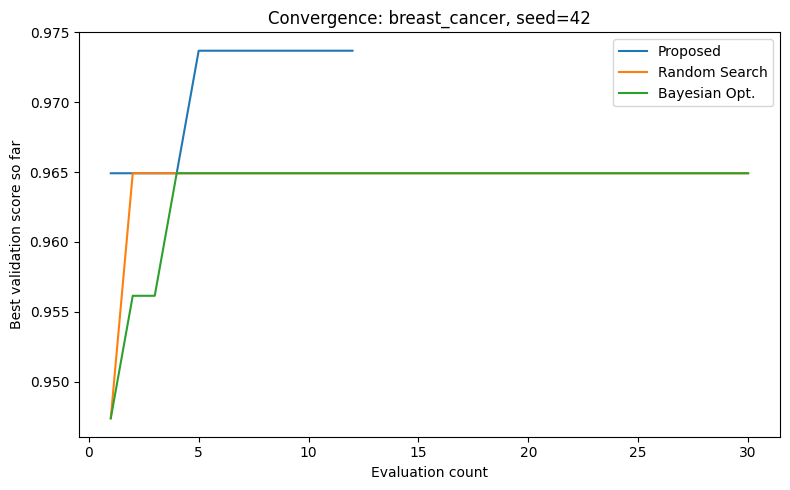

In [ ]:
# convergency plot
plot_convergence_one_dataset_seed(all_results, dataset_name="breast_cancer", seed=42)

In [ ]:
# ablation study
print(ablation_lambda(load_dataset_breast_cancer))
print(ablation_initialization(load_dataset_breast_cancer)[["init_id", "best_score", "best_accuracy"]])
print(ablation_dimension(load_dataset_breast_cancer))

   lambda  best_score  best_accuracy  best_logloss
0  0.0001    0.973684       0.973684      0.117219
1  0.0010    0.973684       0.973684      0.116578
2  0.0100    0.973684       0.973684      0.114858
3  0.1000    0.964912       0.964912      0.118029
4  1.0000    0.973684       0.973684      0.110308
   init_id  best_score  best_accuracy
0        0    0.964912       0.964912
1        1    0.973684       0.973684
2        2    0.973684       0.973684
   n_params                                        param_order  best_score  \
0         2                         (learning_rate, subsample)    0.973684   
1         3       (learning_rate, subsample, colsample_bytree)    0.973684   
2         4  (learning_rate, subsample, colsample_bytree, r...    0.973684   

   best_accuracy  best_logloss  
0       0.973684      0.113976  
1       0.973684      0.115008  
2       0.973684      0.114858  
